In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

In [18]:
#Window Partition Function
def window_partition(x,win):
  batch_size,height,width,embed_dim=x.shape #(1, 8, 8, 3) here 3 is taken as example for embed_dim
  x=x.view(batch_size,height//win,win,width//win,win,embed_dim) #(1, 2, 4, 2, 4, 3)
  x=x.permute(0,1,3,2,4,5) #(1, 2, 2, 4, 4, 3)
  x=x.reshape(-1,win,win,embed_dim) #(4, 4, 4, 3) here first 4 is 1*2*2
  return x

#Window Reverse Function
def window_reverse(windows,win,height,width): #windows-window partition output
  #getting batch size from the reshaped window based input-windows
  #windows-(4, 4, 4, 3)
  batch_size=windows.shape[0]//((height//win)*(width//win)) #eg-4/((8/4)*(8/4))=1 1 is the batch size
  #splitting the window according to the batch size and window size
  x=windows.view(batch_size,height//win,width//win,win,win,-1)#(1, 2, 2, 4, 4, 3)
  x=x.permute(0,1,3,2,4,5) #(1, 2, 4, 2, 4, 3)
  #reshaping to old dimension
  x=x.reshape(batch_size,height,width,-1)#(1, 8, 8, 3)
  return x


In [19]:
#class for calculating attention inisde each window

class WindowAttention(nn.Module):
  def __init__(self,embed_dim,num_heads,win):
    super().__init__()

    self.embed_dim=embed_dim
    self.num_heads=num_heads

    #dimension for each head
    self.head_dim=self.embed_dim//self.num_heads

    #squareroot(dimensions of keys) for calculating attention
    self.scale=self.head_dim**-0.5

    #query,key,value
    self.q=nn.Linear(embed_dim,embed_dim)
    self.k=nn.Linear(embed_dim,embed_dim)
    self.v=nn.Linear(embed_dim,embed_dim)

    self.proj=nn.Linear(embed_dim,embed_dim)


    #realtive positional bias table
    coords=torch.stack(torch.meshgrid(torch.arange(win),torch.arange(win),indexing="ij"))

    coords_flat=coords.flatten(1)

    #relative coordinates
    rel=coords_flat[:,:,None]-coords_flat[:,None,:]
    rel=rel.permute(1,2,0)

    #avoiding negative values (-2 to 2) becomes (0 t0 4)
    rel[:,:,0]=rel[:,:,0]+(win-1)
    rel[:,:,1]=rel[:,:,1]+(win-1)

    #scaling
    rel[:,:,0]=rel[:,:,0]*(2*win-1)
    index=rel.sum(-1)
    self.register_buffer("pos_index",index)
    self.rel_bias=nn.Parameter(torch.zeros((2*win-1)*(2*win-1),num_heads))

  def forward(self, x, mask=None):

    batch_size, n, embed_dim = x.shape
    # Example:
    # batch_size = 8  (2 images × 4 windows)
    # n = 16          (4x4 tokens)
    # embed_dim = 96
    # num_heads = 3
    # head_dim = 32

    q = self.q(x)
    k = self.k(x)
    v = self.v(x)
    # (8,16,96)

    q = q.view(batch_size, n, self.num_heads, embed_dim // self.num_heads).transpose(1, 2)
    k = k.view(batch_size, n, self.num_heads, embed_dim // self.num_heads).transpose(1, 2)
    v = v.view(batch_size, n, self.num_heads, embed_dim // self.num_heads).transpose(1, 2)

    # Now:
    # q, k, v = (8, num_heads, 16, 32)

    q = q * self.scale

    attn = q @ k.transpose(-2, -1)
    # (8,heads,16,32) @ (8,heads,32,16)
    # → (8,heads,16,16)

    rb = self.rel_bias[self.pos_index.view(-1)].view(n, n, -1)
    # (16,16,heads)

    attn = attn + rb.permute(2, 0, 1).unsqueeze(0)
    # rb → (1,heads,16,16)
    # attn stays (8,heads,16,16)

    if mask is not None:
        no_windows = mask.shape[0]

        attn = attn.view(batch_size // no_windows,
                         no_windows,
                         self.num_heads,
                         n,
                         n)
        # Example:
        # 8 // 4 = 2
        # (2,4,heads,16,16)

        attn = attn + mask.unsqueeze(1).unsqueeze(0)

        attn = attn.view(-1, self.num_heads, n, n)
        # back to (8,heads,16,16)

    attn = attn.softmax(dim=-1)

    out = attn @ v
    # (8,heads,16,16) @ (8,heads,16,32)
    # → (8,heads,16,32)

    out = out.transpose(1, 2).reshape(batch_size, n, embed_dim)
    # (8,16,96)

    out = self.proj(out)

    return out

In [20]:
win=3
coords=torch.stack(torch.meshgrid(torch.arange(win),torch.arange(win),indexing="ij"))
# print(coords)
coords_flat=coords.flatten(1)
# print(coords_flat)
print(coords_flat.shape)
rel=coords_flat[:,:,None]-coords_flat[:,None,:]
print(rel)
rel=rel.permute(1,2,0)
print(rel)
#avoiding negative values (-2 to 2) becomes (0 t0 4)
rel[:,:,0]=rel[:,:,0]+(win-1)
rel[:,:,1]=rel[:,:,1]+(win-1)

#scaling
rel[:,:,0]=rel[:,:,0]*(2*win-1)
index=rel.sum(-1 )
print(index)

torch.Size([2, 9])
tensor([[[ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 0,  0,  0, -1, -1, -1, -2, -2, -2],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 1,  1,  1,  0,  0,  0, -1, -1, -1],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0],
         [ 2,  2,  2,  1,  1,  1,  0,  0,  0]],

        [[ 0, -1, -2,  0, -1, -2,  0, -1, -2],
         [ 1,  0, -1,  1,  0, -1,  1,  0, -1],
         [ 2,  1,  0,  2,  1,  0,  2,  1,  0],
         [ 0, -1, -2,  0, -1, -2,  0, -1, -2],
         [ 1,  0, -1,  1,  0, -1,  1,  0, -1],
         [ 2,  1,  0,  2,  1,  0,  2,  1,  0],
         [ 0, -1, -2,  0, -1, -2,  0, -1, -2],
         [ 1,  0, -1,  1,  0, -1,  1,  0, -1],
         [ 2,  1,  0,  2,  1,  0,  2,  1,  0]]])
tensor([[[ 0,  0],
         [ 0, -1],
         [ 0, -2],
         [-1,  0],
         [-1, -1],
         [-1, -2],
         [-2,  0]

In [21]:
#Swin Block

class SwinBlock(nn.Module):
  def __init__(self,embed_dim,res,win,shift,heads):
    super().__init__()
    self.embed_dim=embed_dim
    self.res=res
    self.win=win

    self.shift=shift #for shifting window

    self.norm1=nn.LayerNorm(embed_dim)
    self.attn=WindowAttention(embed_dim,heads,win)

    self.norm2=nn.LayerNorm(embed_dim)
    self.mlp=nn.Sequential(
        nn.Linear(embed_dim,4*embed_dim),
        nn.GELU(),
        nn.Linear(4*embed_dim,embed_dim),
    )

    H,W=res #height,width

    if shift>0:
      self.mask=self.create_mask(H,W,win,shift)
    else:
      self.mask=None

  def create_mask(self,height,width,win,shift):
    img_mask=torch.zeros((1,height,width,1))
    count=0

    for h in ((slice(0,-win)),(slice(-win,-shift)),(slice(-shift,None))):
      for w in ((slice(0,-win)),(slice(-win,-shift)),(slice(-shift,None))):
        img_mask[:,h,w,:]=count
        count+=1

    mask=window_partition(img_mask,win)
    mask=mask.view(-1,win*win)
    mask=mask.unsqueeze(1)-mask.unsqueeze(2)
    mask=mask.masked_fill_(mask!=0,-10000.0)
    return mask

  def forward(self,x):
    batch_size,length,channel=x.shape

    H,W=self.res

    residual=x

    x=self.norm1(x)
    x=x.view(batch_size,H,W,channel)

    if self.shift>0:
      x=torch.roll(x,shifts=(-self.shift,-self.shift),dims=(1,2))

    win_x=window_partition(x,self.win).view(-1,self.win*self.win,channel)

    attn_out=self.attn(win_x,self.mask.to(x.device) if self.mask is not None else None)


    x=window_reverse(attn_out,self.win,H,W)

    if self.shift>0:
      x=torch.roll(x,shifts=(+self.shift,+self.shift),dims=(1,2))

    x=x.view(batch_size,length,channel)+residual

    residual2=x

    x=self.norm2(x)
    x=self.mlp(x)

    x=x+residual2

    return x


In [22]:
class PatchMerging(nn.Module):
  def __init__(self,embed_dim):
    super().__init__()
    self.embed_dim=embed_dim

    self.reduction=nn.Linear(4*embed_dim,2*embed_dim,bias=False)
    self.norm=nn.LayerNorm(4*embed_dim)

  def forward(self,x,H,W):
    B,L,C=x.shape #batch,length,channels

    x=x.view(B,H,W,C)

    x0=x[:,0::2,0::2,:]
    x1=x[:,1::2,0::2,:]
    x2=x[:,0::2,1::2,:]
    x3=x[:,1::2,1::2,:]

    x0=x0.reshape(B,-1,C)
    x1=x1.reshape(B,-1,C)
    x2=x2.reshape(B,-1,C)
    x3=x3.reshape(B,-1,C)

    x=torch.cat([x0,x1,x2,x3],-1)

    x=self.norm(x)
    x=self.reduction(x)

    return x, H//2,W//2


In [36]:
#Swin Block

class Swin(nn.Module):
  def __init__(self,embed_dim=48,heads=3,win=7,num_classes=10):
    super().__init__()
    self.embed_dim=embed_dim
    self.patch_embed=nn.Conv2d(1,embed_dim,kernel_size=2,stride=2)
    initial_resolution=(14,14)

    #stage1
    self.stage1_blocks=nn.Sequential(
        SwinBlock(embed_dim,initial_resolution,heads=heads,win=win,shift=0),
        SwinBlock(embed_dim,initial_resolution,heads=heads,win=win,shift=3)
    )

    self.patch_merge=PatchMerging(embed_dim)
    merged_dim=embed_dim*2
    stage2_res=(initial_resolution[0]//2,initial_resolution[1]//2)
    # #stage2
    self.stage2_blocks=nn.Sequential(
        SwinBlock(merged_dim,stage2_res,heads=heads,win=win,shift=0),#win=win//2 since mnist is very small pixel data keeping window as it is
        SwinBlock(merged_dim,stage2_res,heads=heads,win=win,shift=win//2)#win=win//2,shift=win//4
    )

    self.norm=nn.LayerNorm(merged_dim)
    self.fc=nn.Linear(merged_dim,num_classes)

  def forward(self,x):
    x=self.patch_embed(x)
    B,C,H,W=x.shape

    x=x.flatten(2).transpose(1,2)
    L=H*W

    x=self.stage1_blocks(x)
    x,H,W=self.patch_merge(x,H,W)

    L=H*W
    C=C*2

    x=self.stage2_blocks(x)

    x=self.norm(x)

    x=x.mean(dim=1)

    x=self.fc(x)

    return x

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

train_data=datasets.MNIST("./data",train=True,download=True,transform=transform)
test_data=datasets.MNIST("./data",train=False,download=True,transform=transform)


train_loader=DataLoader(train_data,batch_size=128,shuffle=True)
test_loader=DataLoader(test_data,batch_size=128,shuffle=False)

model=Swin().to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=3e-4)
loss_fn=nn.CrossEntropyLoss()


In [39]:
def test(model):
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for img,label in test_loader:
      img=img.to(device);label=label.to(device);
      out=model(img)
      pred=out.argmax(1)
      correct+=pred.eq(label).sum().item()
      total+=label.size(0)
  return correct / total

for epoch in range(3):
  model.train()
  for img,label in train_loader:
      img=img.to(device);label=label.to(device);
      out=model(img)
      loss=loss_fn(out,label)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  acc=test(model)
  print("Epoch", epoch+1, "Accuracy =",acc*100)



Epoch 1 Accuracy = 94.04
Epoch 2 Accuracy = 94.25
Epoch 3 Accuracy = 96.14


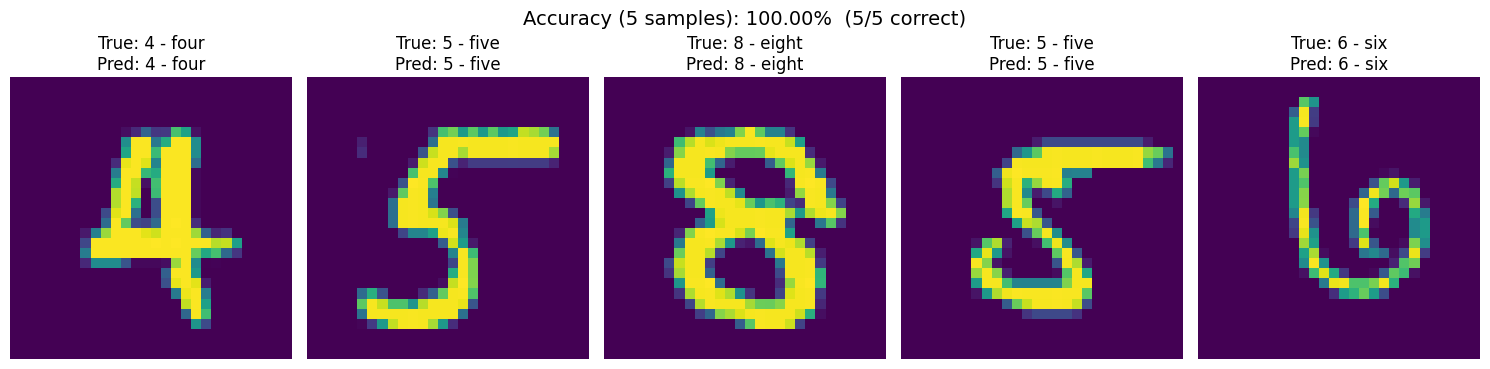

In [46]:
import torch
import matplotlib.pyplot as plt

model.eval()

class_names = train_loader.dataset.classes

# Get one batch
images, labels = next(iter(train_loader))

# Take first 5 images
images = images[:5].to(device)
labels = labels[:5].to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# Move to CPU for plotting
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# Calculate accuracy for these 5 images
correct = (preds == labels).sum().item()
accuracy = correct / 5 * 100

# Plot images
plt.figure(figsize=(15, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    img = images[i].permute(1, 2, 0)  # (C,H,W) → (H,W,C)

    plt.imshow(img)
    plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    plt.axis("off")

plt.suptitle(f"Accuracy (5 samples): {accuracy:.2f}%  ({correct}/5 correct)", fontsize=14)
plt.tight_layout()
plt.show()